# VII. Explainability (XAI) — Transformer Classifier

Notebook de explicabilidad del modelo **GLU-Transformer** entrenado sobre datos de interacción del OULAD.

**Estrategia dual:**
1. **Intrínseca** — Extracción de mapas de atención por capa/cabeza para entender el foco temporal del modelo.
2. **Agnóstica** — SHAP (KernelExplainer) para cuantificar la contribución de cada variable (secuencial + estática) a la predicción.
3. **Análisis de errores** — Inspección de los casos más difíciles para el modelo.

> **Split analizado**: Validación  
> **Objetivo**: generar evidencia accionable para intervención educativa temprana.

## 1) Setup, dependencias y configuración

In [1]:
import os
import sys

sys.path.insert(0, '/workspace/TFM_education_ai_analytics')

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_USE_LEGACY_KERAS'] = '0'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
os.environ['CUDA_CACHE_DISABLE'] = '1'

EXECUTION_DEVICE = 'gpu'
if EXECUTION_DEVICE == 'cpu':
    os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
    print('✅ Ejecución forzada en CPU.')
else:
    print('✅ Ejecutando con la ruta GPU actual del proyecto.')

✅ Ejecutando con la ruta GPU actual del proyecto.


In [2]:
import os
import sys
import json
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.metrics import (
    classification_report, confusion_matrix, balanced_accuracy_score,
    roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score,
    precision_score, recall_score, f1_score,
)

# ─── Estilo visual ────────────────────────────────────────────────────────────
DARK_BG   = '#0F1117'
PANEL_BG  = '#1A1D27'
GRID_CLR  = '#2A2D3A'
TEXT_CLR  = '#E8EAED'

plt.rcParams.update({
    'figure.facecolor': DARK_BG,
    'axes.facecolor':   PANEL_BG,
    'text.color':       TEXT_CLR,
    'axes.labelcolor':  TEXT_CLR,
    'xtick.color':      TEXT_CLR,
    'ytick.color':      TEXT_CLR,
    'axes.edgecolor':   GRID_CLR,
    'grid.color':       GRID_CLR,
    'grid.linestyle':   '--',
    'grid.alpha':       0.4,
    'font.family':      'sans-serif',
    'font.sans-serif':  ['DejaVu Sans'],
})
np.set_printoptions(suppress=True, precision=4)

# ─── Proyecto ─────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path('/workspace/TFM_education_ai_analytics')
os.chdir(PROJECT_ROOT)

# ═══════════════════════════════════════════════════════════════════════════════
# CONFIGURACIÓN DEL EXPERIMENTO  (✏️ editar aquí)
# ═══════════════════════════════════════════════════════════════════════════════
UPTO_WEEK    = 5
SPLIT        = 'validation'
NUM_CLASSES  = 2
BINARY_MODE  = 'paper'          # paper | original | success_vs_risk
WITH_STATIC  = True

# Derivar rutas automáticamente
TARGET_TAG   = f'{NUM_CLASSES}clases_{BINARY_MODE}' if NUM_CLASSES == 2 else f'{NUM_CLASSES}clases'
DATA_DIR     = PROJECT_ROOT / 'data' / '6_transformer_features'
MODEL_PATH   = PROJECT_ROOT / 'models' / 'transformers' / f'transformer_uptoW{UPTO_WEEK}_{TARGET_TAG}.keras'
HISTORY_PATH = PROJECT_ROOT / 'reports' / 'transformer_training' / f'week_{UPTO_WEEK}' / f'experiments_history_{TARGET_TAG}.json'
REPORT_DIR   = PROJECT_ROOT / 'reports' / 'transformer_training' / f'week_{UPTO_WEEK}'
HARDEST_CSV  = REPORT_DIR / f'hardest_val_examples_uptoW{UPTO_WEEK}_{TARGET_TAG}.csv'

print(f'Configuración:')
print(f'  Semana          : {UPTO_WEEK}')
print(f'  Split           : {SPLIT}')
print(f'  Clases          : {NUM_CLASSES} ({BINARY_MODE})')
print(f'  Con estáticas   : {WITH_STATIC}')
print(f'  Modelo          : {MODEL_PATH.name} (existe: {MODEL_PATH.exists()})')
print(f'  Historial       : {HISTORY_PATH.name} (existe: {HISTORY_PATH.exists()})')
print(f'  Hardest CSV     : {HARDEST_CSV.name} (existe: {HARDEST_CSV.exists()})')
print(f'  TensorFlow      : {tf.__version__}')

Configuración:
  Semana          : 5
  Split           : validation
  Clases          : 2 (paper)
  Con estáticas   : True
  Modelo          : transformer_uptoW5_2clases_paper.keras (existe: True)
  Historial       : experiments_history_2clases_paper.json (existe: True)
  Hardest CSV     : hardest_val_examples_uptoW5_2clases_paper.csv (existe: True)
  TensorFlow      : 2.22.0-dev0+selfbuilt


## 2) Utilidades para comparativas semanales

Esta sección define utilidades reutilizables para cargar artefactos, filtrar clases y validar compatibilidad entre modelos y datos antes de ejecutar comparativas entre semanas.

In [3]:
mod_path = PROJECT_ROOT / 'educational_ai_analytics' / '2_modeling' / 'transformers' / 'transformer_GLU_classifier.py'
spec = importlib.util.spec_from_file_location('transformer_GLU_classifier', mod_path)
tg = importlib.util.module_from_spec(spec)
spec.loader.exec_module(tg)

GLUTransformerClassifier = tg.GLUTransformerClassifier
TransformerEncoderBlock = tg.TransformerEncoderBlock
GLULayer = tg.GLULayer


def load_npz_split(split: str, upto_week: int, with_static: bool = True):
    fp = DATA_DIR / split / f'transformer_uptoW{upto_week}.npz'
    d = np.load(fp, allow_pickle=True)

    X_seq = d['X_seq'].astype(np.float32)
    mask_pad = (d['mask_pad'] if 'mask_pad' in d.files else d['mask']).astype(np.int32)
    mask_activity = (d['mask_activity'] if 'mask_activity' in d.files else mask_pad).astype(np.int32)
    y = d['y'].astype(np.int64)
    ids = d['ids'].astype(str)

    X_static = d['X_static'].astype(np.float32) if with_static else None

    static_feature_names = d['static_feature_names'] if 'static_feature_names' in d.files else np.array([], dtype=object)
    static_feature_sources = d['static_feature_sources'] if 'static_feature_sources' in d.files else np.array([], dtype=object)
    activities = d['activities'] if 'activities' in d.files else np.array([], dtype=object)

    return {
        'X_seq': X_seq,
        'mask_pad': mask_pad,
        'mask_activity': mask_activity,
        'y': y,
        'ids': ids,
        'X_static': X_static,
        'static_feature_names': static_feature_names,
        'static_feature_sources': static_feature_sources,
        'activities': activities,
    }


def filter_classes_binary(payload, binary_mode: str):
    y = payload['y']

    if binary_mode == 'paper':
        keep = y != 1
        y_bin = np.where(y[keep] == 0, 1, 0).astype(np.int64)
    elif binary_mode == 'original':
        keep = y != 0
        y_kept = y[keep]
        y_bin = np.where(y_kept == 1, 1, 0).astype(np.int64)
    elif binary_mode == 'success_vs_risk':
        keep = np.ones(len(y), dtype=bool)
        y_bin = np.where(y < 2, 1, 0).astype(np.int64)
    else:
        raise ValueError(f'binary_mode desconocido: {binary_mode}')

    result = {}
    for k, v in payload.items():
        if isinstance(v, np.ndarray) and v.shape[0] == len(y):
            result[k] = v[keep]
        else:
            result[k] = v
    result['y'] = y_bin
    return result


def load_model_from_history(model_path, history_path, upto_week):
    hist = json.loads(history_path.read_text(encoding='utf-8'))
    candidates = [r for r in hist if int(r.get('hyperparameters', {}).get('upto_week', -1)) == int(upto_week)]
    if not candidates:
        raise ValueError(f'No hay entradas en historial para upto_week={upto_week}')

    hp = candidates[-1]['hyperparameters']
    custom_objects = {
        'GLUTransformerClassifier': GLUTransformerClassifier,
        'TransformerEncoderBlock': TransformerEncoderBlock,
        'GLULayer': GLULayer,
    }

    model = tf.keras.models.load_model(
        model_path,
        custom_objects=custom_objects,
        compile=False,
    )
    return model, hp


def _week_artifacts(upto_week):
    target_tag = f'{NUM_CLASSES}clases_{BINARY_MODE}' if NUM_CLASSES == 2 else f'{NUM_CLASSES}clases'
    model_path = PROJECT_ROOT / 'models' / 'transformers' / f'transformer_uptoW{upto_week}_{target_tag}.keras'
    history_path = PROJECT_ROOT / 'reports' / 'transformer_training' / f'week_{upto_week}' / f'experiments_history_{target_tag}.json'
    return model_path, history_path


def _expected_static_dim(model_obj):
    if not getattr(model_obj, 'with_static_features', False):
        return 0

    try:
        model_inputs = model_obj.inputs
        inputs = model_inputs if isinstance(model_inputs, (list, tuple)) else [model_inputs]
        if len(inputs) >= 4 and inputs[3].shape[-1] is not None:
            return int(inputs[3].shape[-1])
    except Exception:
        pass

    try:
        first_static_layer = model_obj.static_block.layers[0]
        if hasattr(first_static_layer, 'kernel'):
            return int(first_static_layer.kernel.shape[0])
    except Exception:
        pass

    return None


print('Utilidades cargadas para comparativas semanales.')

Utilidades cargadas para comparativas semanales.


## 10.b) Comparativa compacta de SHAP entre semanas

Esta sección recalcula SHAP para varias ventanas `upto_week` y resume el resultado en una salida compacta:

- una tabla de métricas por ventana
- un heatmap con las features secuenciales más importantes por ventana
- un heatmap de importancia temporal por semana
- un heatmap de variables estáticas si existen

La idea es evitar cinco tablas independientes y quedarse con una vista comparativa única.

Ventanas impares a comparar: [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]


/opt/tfm-venv/lib/python3.12/site-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
/opt/tfm-venv/lib/python3.12/site-packages/keras/src/ops/nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (32, 8, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
 38%|███▊      | 61/160 [00:40<01:04,  1.54it/s]/opt/tfm-venv/lib/python3.12/site-packages/sklearn/linear_model/_least_angle.py:688: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 1 iterations, i.e. alpha=2.242e-02, with an active set of 1 regressors, and the smallest cholesky pivot element being 2.220e-16. Red

Métricas por ventana:


,upto_week,n_samples,accuracy,balanced_accuracy,precision,recall,auc,background_size,explain_size,static_features
0,1,2774,0.653929,0.663654,0.433917,0.686398,0.708513,50,160,65
1,3,3203,0.741180,0.721716,0.557659,0.672897,0.778185,50,160,65
2,5,3252,0.805658,0.759718,0.693654,0.643002,0.828803,50,160,65
3,7,3276,0.826007,0.797994,0.708129,0.726633,0.859248,50,160,65
4,9,3287,0.852145,0.829325,0.748783,0.771314,0.888391,50,160,65
5,11,3290,0.873860,0.839320,0.817884,0.751503,0.903273,50,160,65
6,13,3291,0.877849,0.857450,0.794466,0.805611,0.919868,50,160,65
7,15,3295,0.902276,0.878987,0.852237,0.819820,0.935687,50,160,65
8,17,3297,0.912345,0.891073,0.869159,0.837000,0.946650,50,160,65
9,19,3297,0.929633,0.912515,0.895876,0.869000,0.962951,50,160,65


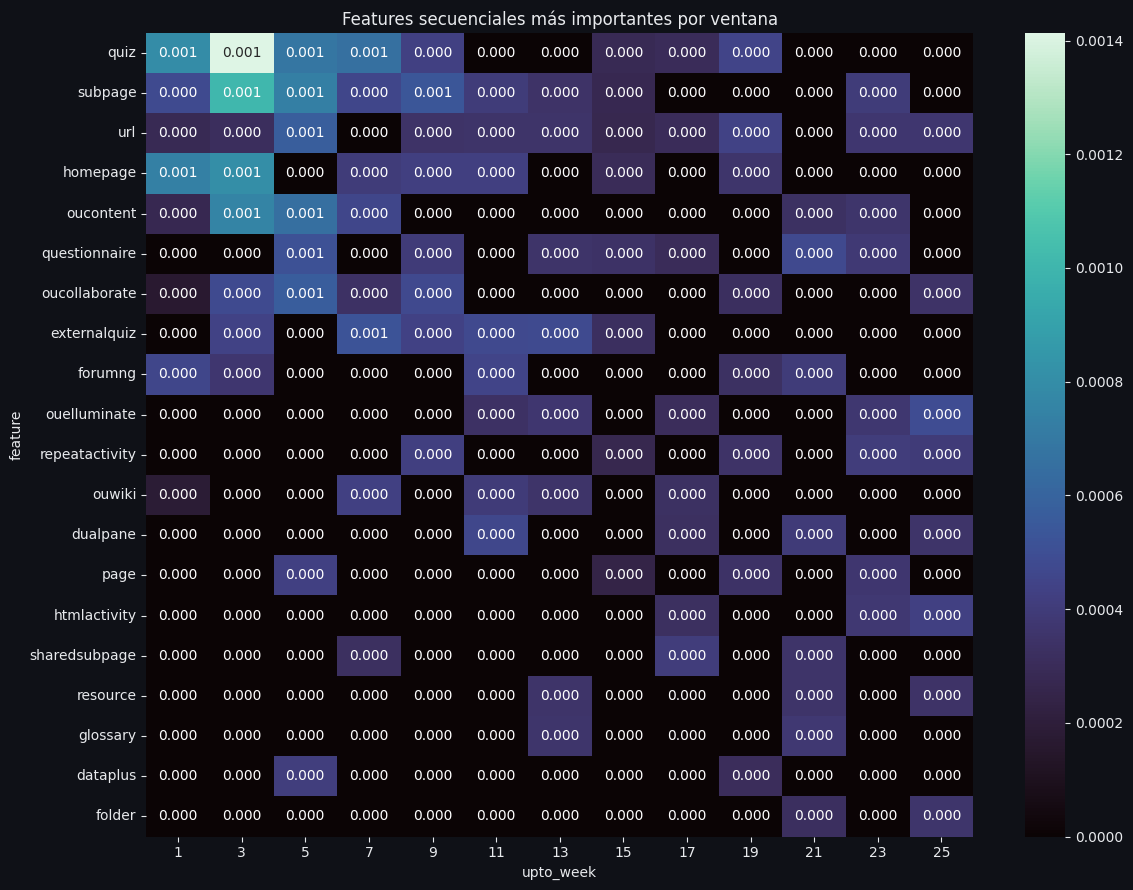

,upto_week,rank,feature,mean_abs_shap
0,1,1,quiz,0.000790
1,1,2,homepage,0.000737
2,1,3,subpage,0.000479
3,1,4,forumng,0.000455
4,1,5,url,0.000287
...,...,...,...,...
99,25,4,url,0.000365
100,25,5,folder,0.000357
101,25,6,dualpane,0.000353
102,25,7,oucollaborate,0.000347


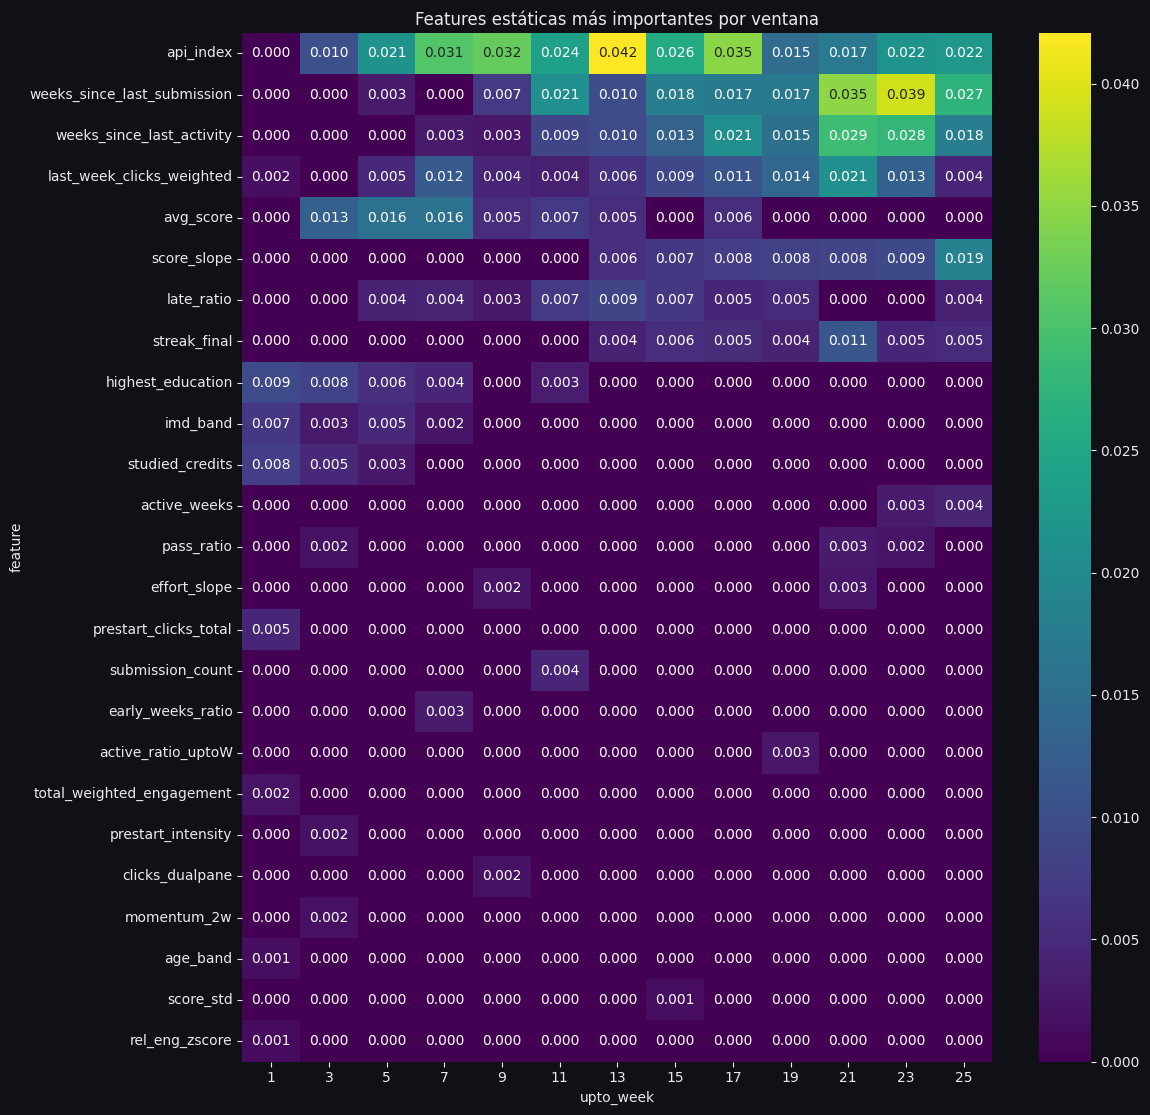

,upto_week,rank,feature,mean_abs_shap
0,1,1,highest_education,0.009412
1,1,2,studied_credits,0.007630
2,1,3,imd_band,0.006652
3,1,4,prestart_clicks_total,0.004563
4,1,5,total_weighted_engagement,0.001996
...,...,...,...,...
99,25,4,weeks_since_last_activity,0.017598
100,25,5,streak_final,0.004998
101,25,6,last_week_clicks_weighted,0.004348
102,25,7,active_weeks,0.004130


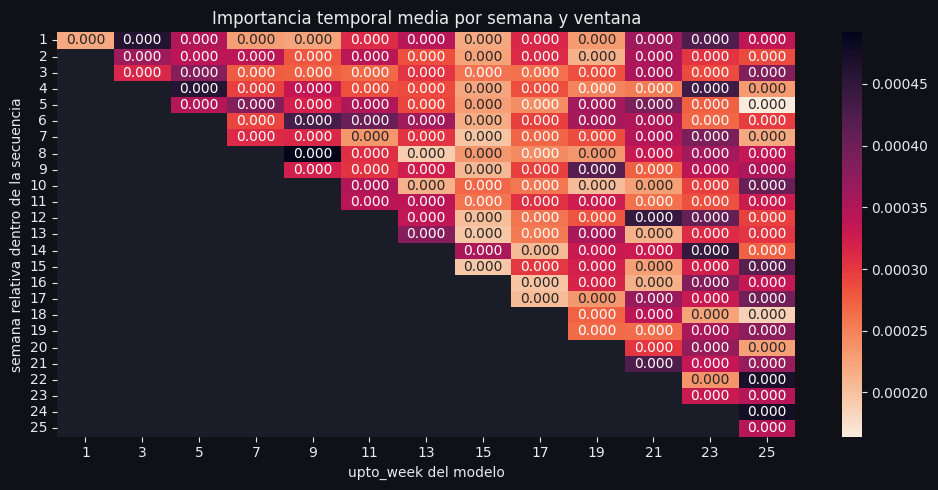

In [7]:
import shap
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

WEEKS_TO_COMPARE = sorted(
    int(path.stem.removeprefix('transformer_uptoW'))
    for path in (DATA_DIR / SPLIT).glob('transformer_uptoW*.npz')
    if path.stem.removeprefix('transformer_uptoW').isdigit()
)
WEEKS_TO_COMPARE = [week for week in WEEKS_TO_COMPARE if week % 2 == 1]

SHAP_BG_SIZE = 50
SHAP_EXPLAIN_SIZE = 160
SHAP_NSAMPLES = 160  # Numero de evaluaciones aproximadas por explicacion SHAP
TOP_K = 8
RNG = np.random.default_rng(42)

print('Ventanas impares a comparar:', WEEKS_TO_COMPARE)

def _normalize_shap_array(shap_values_obj):
    sv_local = shap_values_obj
    if isinstance(sv_local, list):
        sv_local = sv_local[1] if (NUM_CLASSES == 2 and len(sv_local) > 1) else sv_local[0]
    sv_local = np.asarray(sv_local)
    if sv_local.ndim == 3 and sv_local.shape[-1] == 1:
        sv_local = sv_local[..., 0]
    return sv_local

metrics_rows = []
seq_rows = []
static_rows = []
temporal_rows = []

for upto_week in WEEKS_TO_COMPARE:
    model_path, history_path = _week_artifacts(upto_week)
    if not model_path.exists() or not history_path.exists():
        print(f'⚠️ Saltando W={upto_week}: faltan artefactos de modelo o historial.')
        continue

    payload_raw_w = load_npz_split(SPLIT, upto_week, with_static=WITH_STATIC)
    payload_w = filter_classes_binary(payload_raw_w, BINARY_MODE) if NUM_CLASSES == 2 else payload_raw_w

    X_seq_w = payload_w['X_seq']
    mask_pad_w = payload_w['mask_pad']
    mask_activity_w = payload_w['mask_activity']
    X_static_w = payload_w['X_static']
    y_w = payload_w['y']
    activities_w = payload_w['activities']
    static_names_w = payload_w['static_feature_names']

    model_w, hp_w = load_model_from_history(
        model_path=model_path,
        history_path=history_path,
        upto_week=upto_week,
    )

    expected_static_dim_w = _expected_static_dim(model_w)
    actual_static_dim_w = 0 if X_static_w is None else int(X_static_w.shape[1])
    if expected_static_dim_w is not None and expected_static_dim_w != actual_static_dim_w:
        print(
            f'⚠️ Saltando W={upto_week}: el modelo espera {expected_static_dim_w} features estáticas y el NPZ trae {actual_static_dim_w}.'
        )
        tf.keras.backend.clear_session()
        continue

    inputs_w = [X_seq_w, mask_pad_w.astype(np.int32), mask_activity_w.astype(np.int32)]
    if X_static_w is not None:
        inputs_w.append(X_static_w)

    probs_w = model_w.predict(inputs_w, verbose=0)
    y_pred_w = np.argmax(probs_w, axis=1)

    avg_mode = 'binary' if NUM_CLASSES == 2 else 'weighted'

    accuracy_w = float(accuracy_score(y_w, y_pred_w))
    bal_acc_w = float(balanced_accuracy_score(y_w, y_pred_w))
    precision_w = float(precision_score(y_w, y_pred_w, average=avg_mode, zero_division=0))
    recall_w = float(recall_score(y_w, y_pred_w, average=avg_mode, zero_division=0))
    auc_w = (
        float(roc_auc_score(y_w, probs_w[:, 1]))
        if NUM_CLASSES == 2
        else float(roc_auc_score(y_w, probs_w, multi_class='ovr'))
    )

    N_w = len(X_seq_w)
    W_w = X_seq_w.shape[1]
    F_w = X_seq_w.shape[2]
    S_w = 0 if X_static_w is None else X_static_w.shape[1]

    def pack_flat_week(x_seq, x_static=None):
        x_flat = x_seq.reshape(len(x_seq), W_w * F_w)
        if x_static is not None:
            x_flat = np.concatenate([x_flat, x_static], axis=1)
        return x_flat

    def unpack_flat_week(x_flat):
        x_flat = np.asarray(x_flat)
        x_seq_u = x_flat[:, :W_w * F_w].reshape(-1, W_w, F_w).astype(np.float32)
        x_static_u = x_flat[:, W_w * F_w:].astype(np.float32) if S_w > 0 else None
        return x_seq_u, x_static_u

    def build_masks_week(x_seq_u):
        m_activity_u = (np.abs(x_seq_u).sum(axis=2) > 0).astype(np.int32)
        m_pad_u = np.ones_like(m_activity_u, dtype=np.int32)
        return m_pad_u, m_activity_u

    def f_predict_week(x_flat):
        xs, xst = unpack_flat_week(x_flat)
        m_pad_s, m_act_s = build_masks_week(xs)
        ins = [xs, m_pad_s, m_act_s]
        if xst is not None:
            ins.append(xst)
        p = model_w.predict(ins, verbose=0)
        return p[:, 1] if NUM_CLASSES == 2 else np.max(p, axis=1)

    X_flat_w = pack_flat_week(X_seq_w, X_static_w)
    bg_size = min(SHAP_BG_SIZE, N_w)
    ex_size = min(SHAP_EXPLAIN_SIZE, N_w)
    bg_idx_w = RNG.choice(N_w, size=bg_size, replace=False)
    ex_idx_w = RNG.choice(N_w, size=ex_size, replace=False)

    explainer_w = shap.KernelExplainer(f_predict_week, X_flat_w[bg_idx_w])
    shap_values_w = explainer_w.shap_values(X_flat_w[ex_idx_w], nsamples=SHAP_NSAMPLES)
    sv_w = _normalize_shap_array(shap_values_w)

    seq_cols_w = W_w * F_w
    sv_seq_w = sv_w[:, :seq_cols_w].reshape(-1, W_w, F_w)
    imp_wf_w = np.abs(sv_seq_w).mean(axis=0)
    imp_week_w = imp_wf_w.mean(axis=1)
    imp_seq_feat_w = imp_wf_w.mean(axis=0)

    seq_feature_names_w = [str(a) for a in activities_w] if len(activities_w) == F_w else [f'seq_f{i}' for i in range(F_w)]
    df_seq_w = pd.DataFrame({
        'feature': seq_feature_names_w,
        'mean_abs_shap': imp_seq_feat_w,
    }).sort_values('mean_abs_shap', ascending=False).head(TOP_K).reset_index(drop=True)

    for rank, row in enumerate(df_seq_w.itertuples(index=False), start=1):
        seq_rows.append({
            'upto_week': upto_week,
            'rank': rank,
            'feature': row.feature,
            'mean_abs_shap': float(row.mean_abs_shap),
        })

    if S_w > 0:
        static_names_safe_w = [str(s) for s in static_names_w] if len(static_names_w) == S_w else [f'static_f{i}' for i in range(S_w)]
        imp_static_w = np.abs(sv_w[:, seq_cols_w:]).mean(axis=0)
        df_static_w = pd.DataFrame({
            'feature': static_names_safe_w,
            'mean_abs_shap': imp_static_w,
        }).sort_values('mean_abs_shap', ascending=False).head(TOP_K).reset_index(drop=True)

        for rank, row in enumerate(df_static_w.itertuples(index=False), start=1):
            static_rows.append({
                'upto_week': upto_week,
                'rank': rank,
                'feature': row.feature,
                'mean_abs_shap': float(row.mean_abs_shap),
            })

    for week_idx, value in enumerate(imp_week_w, start=1):
        temporal_rows.append({
            'upto_week': upto_week,
            'relative_week': week_idx,
            'mean_abs_shap': float(value),
        })

    metrics_rows.append({
        'upto_week': upto_week,
        'n_samples': N_w,
        'accuracy': accuracy_w,
        'balanced_accuracy': bal_acc_w,
        'precision': precision_w,
        'recall': recall_w,
        'auc': auc_w,
        'background_size': bg_size,
        'explain_size': ex_size,
        'static_features': actual_static_dim_w,
    })

    tf.keras.backend.clear_session()

metrics_multiweek_df = pd.DataFrame(metrics_rows).sort_values('upto_week').reset_index(drop=True)
seq_multiweek_df = pd.DataFrame(seq_rows)
static_multiweek_df = pd.DataFrame(static_rows) if static_rows else pd.DataFrame()
temporal_multiweek_df = pd.DataFrame(temporal_rows)

print('Métricas por ventana:')
display(metrics_multiweek_df)

if not seq_multiweek_df.empty:
    seq_heatmap = seq_multiweek_df.pivot_table(
        index='feature',
        columns='upto_week',
        values='mean_abs_shap',
        aggfunc='max',
        fill_value=0.0,
    )
    seq_heatmap = seq_heatmap.loc[seq_heatmap.mean(axis=1).sort_values(ascending=False).index]
    plt.figure(figsize=(12, max(5, 0.45 * len(seq_heatmap))))
    sns.heatmap(seq_heatmap, cmap='mako', annot=True, fmt='.3f')
    plt.title('Features secuenciales más importantes por ventana')
    plt.xlabel('upto_week')
    plt.ylabel('feature')
    plt.tight_layout()
    plt.show()

display(seq_multiweek_df.sort_values(['upto_week', 'rank']).reset_index(drop=True))

if not static_multiweek_df.empty:
    static_heatmap = static_multiweek_df.pivot_table(
        index='feature',
        columns='upto_week',
        values='mean_abs_shap',
        aggfunc='max',
        fill_value=0.0,
    )
    static_heatmap = static_heatmap.loc[static_heatmap.mean(axis=1).sort_values(ascending=False).index]
    plt.figure(figsize=(12, max(5, 0.45 * len(static_heatmap))))
    sns.heatmap(static_heatmap, cmap='viridis', annot=True, fmt='.3f')
    plt.title('Features estáticas más importantes por ventana')
    plt.xlabel('upto_week')
    plt.ylabel('feature')
    plt.tight_layout()
    plt.show()

display(static_multiweek_df.sort_values(['upto_week', 'rank']).reset_index(drop=True))

if not temporal_multiweek_df.empty:
    temporal_heatmap = temporal_multiweek_df.pivot(
        index='relative_week',
        columns='upto_week',
        values='mean_abs_shap',
    ).sort_index()
    plt.figure(figsize=(10, 5))
    sns.heatmap(temporal_heatmap, cmap='rocket_r', annot=True, fmt='.3f')
    plt.title('Importancia temporal media por semana y ventana')
    plt.xlabel('upto_week del modelo')
    plt.ylabel('semana relativa dentro de la secuencia')
    plt.tight_layout()
    plt.show()

## 4) Comparativa compacta de atención entre semanas impares

Esta sección replica el análisis intrínseco de atención para las ventanas semanales impares disponibles y lo resume sin generar una salida repetitiva por cada modelo.

Se muestran:

- una tabla con la semana más atendida por cada `upto_week`
- un heatmap de atención media recibida por semana relativa
- una rejilla con la matriz de self-attention media de la última capa para cada ventana

Resumen de atención por ventana:


,upto_week,n_attn_samples,num_layers,top_attention_week,top_attention_received
0,5,128,2,5,0.238975
1,10,128,2,10,0.153413
2,15,128,2,3,0.081197
3,20,128,2,2,0.067653
4,25,128,2,23,0.057428


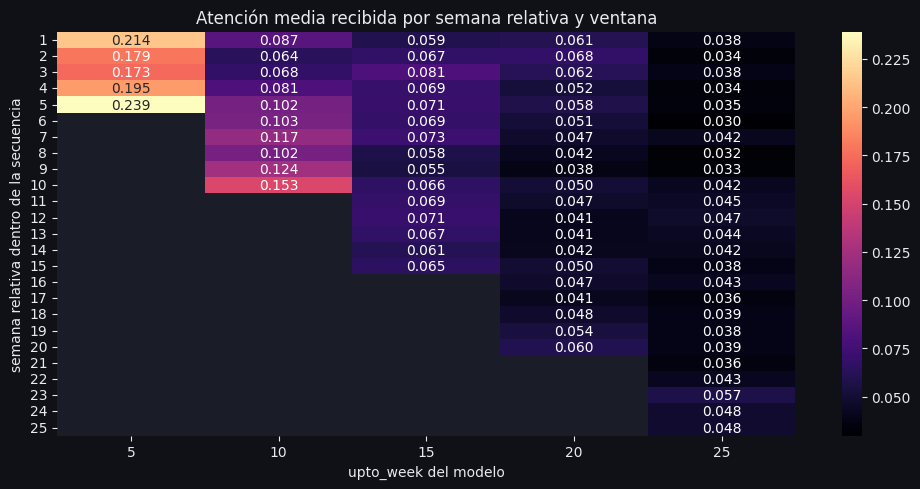

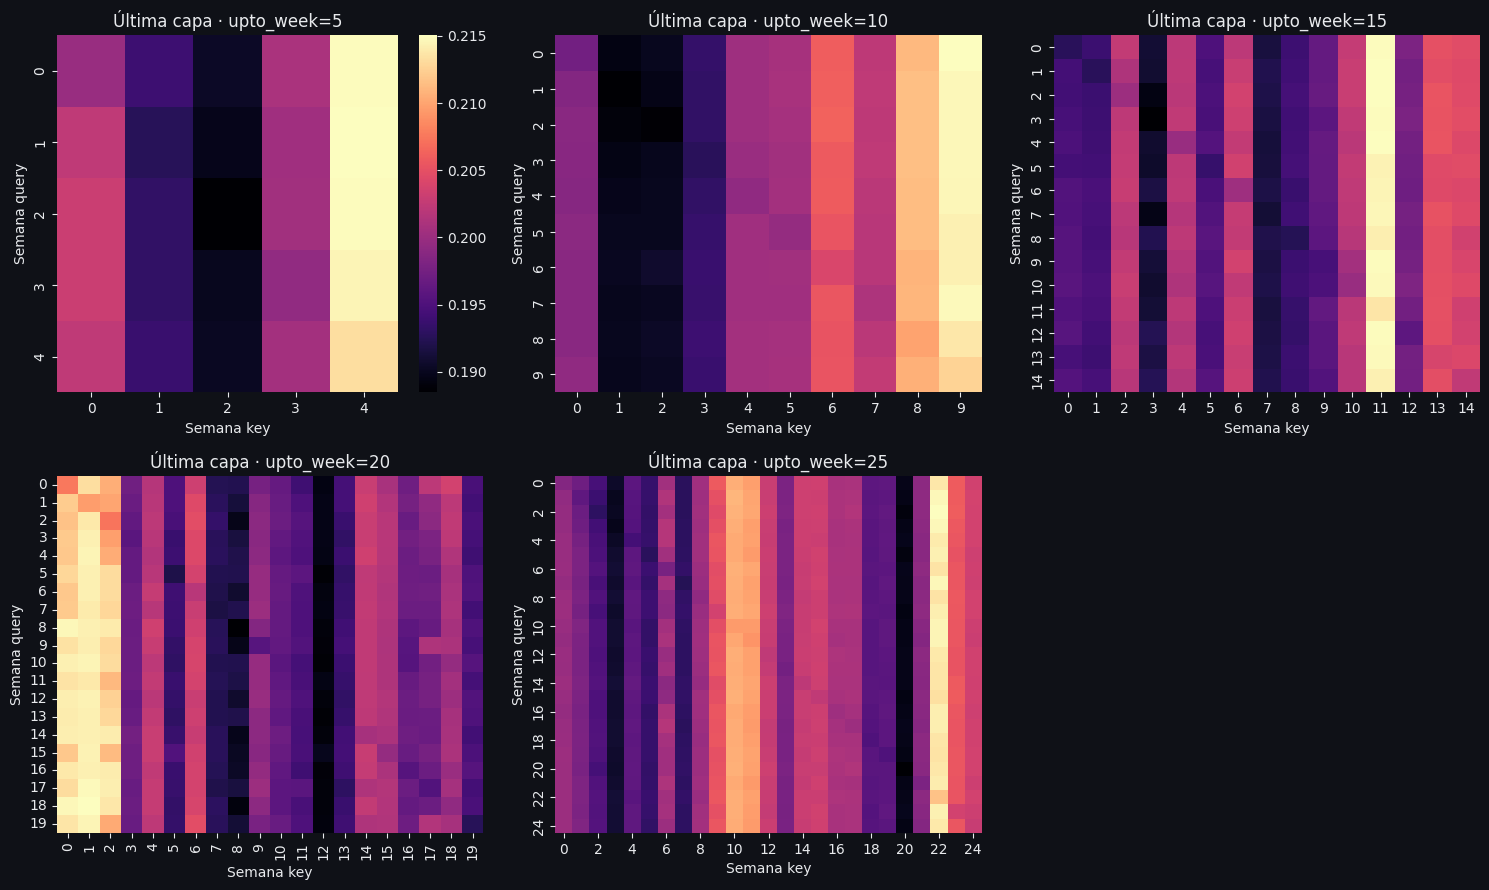

In [ ]:
import math


def extract_attention_summary(model_obj, x_seq_np, mask_pad_np, mask_activity_np, x_static_np=None, max_samples=128):
    n_attn_local = min(max_samples, len(x_seq_np))
    x_seq_local = tf.convert_to_tensor(x_seq_np[:n_attn_local], dtype=tf.float32)
    seq_mask_local = tf.convert_to_tensor(mask_pad_np[:n_attn_local].astype(np.int32))
    act_mask_local = tf.convert_to_tensor(mask_activity_np[:n_attn_local].astype(np.int32))

    if x_static_np is not None:
        x_static_local = tf.convert_to_tensor(x_static_np[:n_attn_local], dtype=tf.float32)
    else:
        x_static_local = None

    x_local = model_obj.input_proj(x_seq_local)

    if getattr(model_obj, 'with_static_features', False) and (x_static_local is not None):
        x_static_emb_local = model_obj.static_block(x_static_local, training=False)
        x_static_t_local = tf.expand_dims(x_static_emb_local, axis=1)
        x_static_t_local = tf.broadcast_to(x_static_t_local, tf.shape(x_local))
        fusion_in_local = tf.concat([x_local, x_static_t_local], axis=-1)
        gate_local = model_obj.fusion_gate(fusion_in_local)
        x_local = (1.0 - gate_local) * x_local + gate_local * x_static_t_local

    x_local = model_obj.in_drop(x_local, training=False)

    attn_layers_local = []
    for enc_local in model_obj.encoders:
        attn_mask_local = enc_local.make_attn_mask(seq_mask_local)
        h_local = enc_local.norm_attn(x_local)
        attn_out_local, attn_scores_local = enc_local.mha(
            h_local, h_local, h_local,
            attention_mask=attn_mask_local,
            return_attention_scores=True,
            training=False,
        )
        attn_out_local = enc_local.drop_attn(attn_out_local, training=False)
        x_local = x_local + attn_out_local

        h2_local = enc_local.norm_ffn(x_local)
        ffn_local = enc_local.ffn_glu(h2_local)
        ffn_local = enc_local.ffn_out(ffn_local)
        ffn_local = enc_local.drop_ffn(ffn_local, training=False)
        x_local = x_local + ffn_local

        attn_array = attn_scores_local.numpy()
        if attn_array.ndim == 3:
            attn_array = attn_array[:, None, :, :]
        attn_layers_local.append(attn_array)

    attn_mean_by_layer_local = [a.mean(axis=(0, 1)) for a in attn_layers_local]
    attn_all_local = np.stack(attn_layers_local, axis=0)
    attn_week_importance_local = attn_all_local.mean(axis=(0, 1, 2, 3))

    return {
        'n_attn': n_attn_local,
        'num_layers': len(attn_layers_local),
        'attn_mean_by_layer': attn_mean_by_layer_local,
        'attn_week_importance': attn_week_importance_local,
    }


attention_rows = []
attention_temporal_rows = []
attention_last_layer_maps = {}

for upto_week in WEEKS_TO_COMPARE:
    model_path, history_path = _week_artifacts(upto_week)
    if not model_path.exists() or not history_path.exists():
        print(f'⚠️ Saltando W={upto_week}: faltan artefactos de modelo o historial.')
        continue

    payload_raw_w = load_npz_split(SPLIT, upto_week, with_static=WITH_STATIC)
    payload_w = filter_classes_binary(payload_raw_w, BINARY_MODE) if NUM_CLASSES == 2 else payload_raw_w

    X_seq_w = payload_w['X_seq']
    mask_pad_w = payload_w['mask_pad']
    mask_activity_w = payload_w['mask_activity']
    X_static_w = payload_w['X_static']

    model_w, hp_w = load_model_from_history(
        model_path=model_path,
        history_path=history_path,
        upto_week=upto_week,
    )

    expected_static_dim_w = _expected_static_dim(model_w)
    actual_static_dim_w = 0 if X_static_w is None else int(X_static_w.shape[1])
    if expected_static_dim_w is not None and expected_static_dim_w != actual_static_dim_w:
        print(
            f'⚠️ Saltando W={upto_week}: el modelo espera {expected_static_dim_w} features estáticas y el NPZ trae {actual_static_dim_w}.'
        )
        tf.keras.backend.clear_session()
        continue

    attention_summary_w = extract_attention_summary(
        model_obj=model_w,
        x_seq_np=X_seq_w,
        mask_pad_np=mask_pad_w,
        mask_activity_np=mask_activity_w,
        x_static_np=X_static_w,
    )

    week_importance_w = attention_summary_w['attn_week_importance']
    top_week_idx = int(np.argmax(week_importance_w)) + 1

    attention_rows.append({
        'upto_week': upto_week,
        'n_attn_samples': attention_summary_w['n_attn'],
        'num_layers': attention_summary_w['num_layers'],
        'top_attention_week': top_week_idx,
        'top_attention_received': float(week_importance_w[top_week_idx - 1]),
        'static_features': actual_static_dim_w,
    })

    for relative_week, value in enumerate(week_importance_w, start=1):
        attention_temporal_rows.append({
            'upto_week': upto_week,
            'relative_week': relative_week,
            'attention_received': float(value),
        })

    attention_last_layer_maps[upto_week] = attention_summary_w['attn_mean_by_layer'][-1]
    tf.keras.backend.clear_session()

attention_multiweek_df = pd.DataFrame(attention_rows).sort_values('upto_week').reset_index(drop=True)
attention_temporal_df = pd.DataFrame(attention_temporal_rows)

print('Resumen de atención por ventana:')
display(attention_multiweek_df)

if not attention_temporal_df.empty:
    attention_temporal_heatmap = attention_temporal_df.pivot(
        index='relative_week',
        columns='upto_week',
        values='attention_received',
    ).sort_index()

    plt.figure(figsize=(10, 5))
    sns.heatmap(attention_temporal_heatmap, cmap='magma', annot=True, fmt='.3f')
    plt.title('Atención media recibida por semana relativa y ventana')
    plt.xlabel('upto_week del modelo')
    plt.ylabel('semana relativa dentro de la secuencia')
    plt.tight_layout()
    plt.show()

if attention_last_layer_maps:
    ordered_weeks = sorted(attention_last_layer_maps)
    n_cols = min(3, len(ordered_weeks))
    n_rows = math.ceil(len(ordered_weeks) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, upto_week in zip(axes, ordered_weeks):
        sns.heatmap(attention_last_layer_maps[upto_week], cmap='magma', ax=ax, cbar=ax is axes[0])
        ax.set_title(f'Última capa · upto_week={upto_week}')
        ax.set_xlabel('Semana key')
        ax.set_ylabel('Semana query')

    for ax in axes[len(ordered_weeks):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()